## setup

In [1]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F
import optuna
import numpy as np
import torch
import torch.nn as nn

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from torch.utils.data import TensorDataset, DataLoader


/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np

# Load feature arrays
X_list = []
for i in range(1, 10):
    X = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}.npy").astype(np.float32)
    #X = X[:, None, :, :]      
    X_list.append(X)

# Combine into one dataset
X = np.concatenate(X_list, axis=0)

print("X shape:", X.shape)


# Load label arrays
y_list = []
for i in range(1, 10):
    y = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}L.npy")
    y_list.append(y)

# Combine labels
y = np.concatenate(y_list, axis=0)

print("y shape:", y.shape)


X shape: (5184, 22, 1001)
y shape: (5184,)


## variances

In [12]:
amp=np.max(np.abs(X), axis=(1,2))

for c in np.unique(y):
    class_amp = amp[y == c]
    print(f"Class {c}: min={class_amp.min()}, max={class_amp.max()}, mean={class_amp.mean()}, std={class_amp.std()}")

Class feet: min=12.455840110778809, max=72.03547668457031, mean=27.0615177154541, std=8.558430671691895
Class left_hand: min=12.195549964904785, max=71.28426361083984, mean=25.583206176757812, std=8.699012756347656
Class right_hand: min=13.19770622253418, max=77.55209350585938, mean=25.86295509338379, std=8.599945068359375
Class tongue: min=13.02138614654541, max=91.24015045166016, mean=28.792028427124023, std=10.571284294128418


In [13]:
trial_var = np.var(X, axis=(1, 2))

for c in np.unique(y):
    vals = trial_var[y == c]
    print(c, "mean variance:", vals.mean(), "std:", vals.std())

feet mean variance: 41.47232 std: 26.608982
left_hand mean variance: 37.750755 std: 29.394285
right_hand mean variance: 38.51722 std: 25.890461
tongue mean variance: 47.30334 std: 33.012573


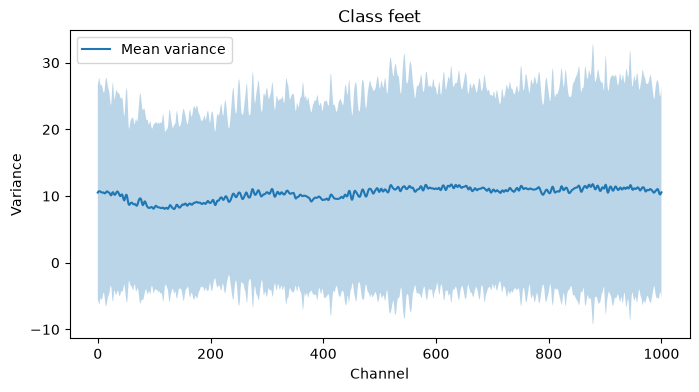

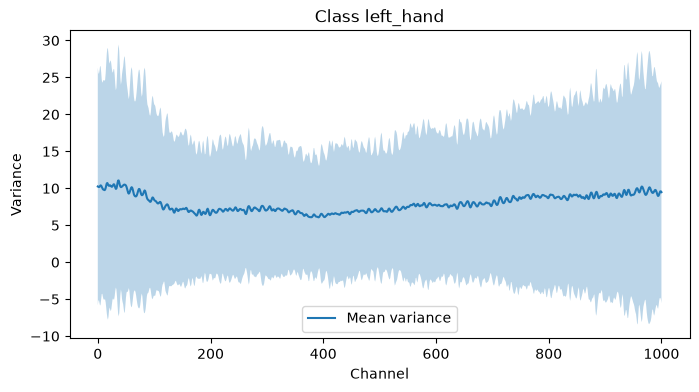

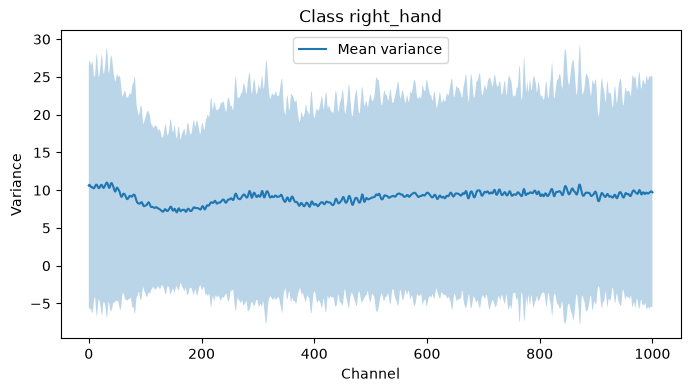

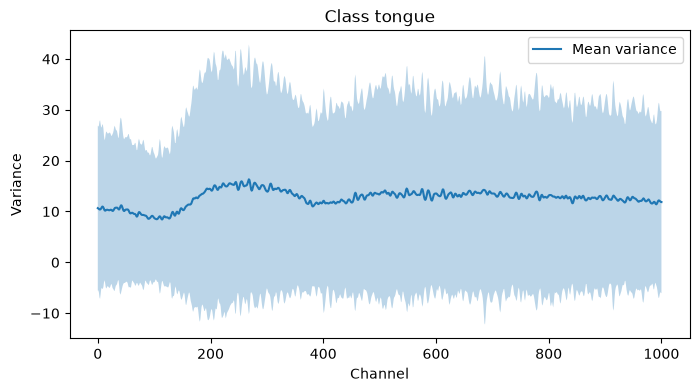

In [14]:
import numpy as np
import matplotlib.pyplot as plt

channel_var = np.var(X, axis=1)  # trials x channels

for c in np.unique(y):
    vals = channel_var[y == c]   # trials x channels

    mean = vals.mean(axis=0)
    std = vals.std(axis=0)

    plt.figure(figsize=(8,4))
    plt.plot(mean, label="Mean variance")
    plt.fill_between(
        np.arange(mean.shape[0]),
        mean - std,
        mean + std,
        alpha=0.3
    )

    plt.title(f"Class {c}")
    plt.xlabel("Channel")
    plt.ylabel("Variance")
    plt.legend()
    plt.show()

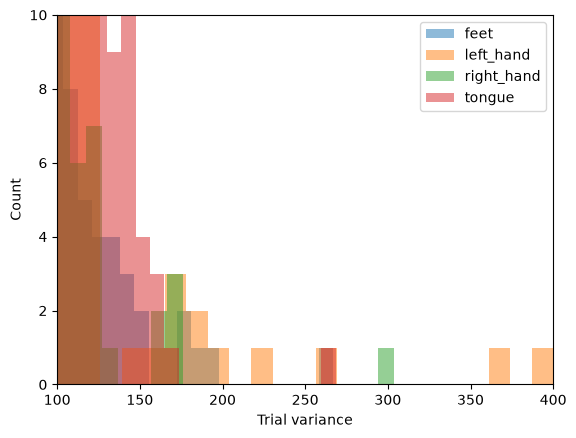

In [24]:
import matplotlib.pyplot as plt
max=0
for c in np.unique(y):
    plt.hist(trial_var[y == c], alpha=0.5, label=str(c), bins=30)
    if trial_var[y == c].max() > max:
        max = trial_var[y == c].max()

plt.xlabel("Trial variance")
plt.ylabel("Count")
plt.legend()
plt.xlim(100, 400)
plt.ylim(0,10)
plt.show()


In [26]:
trial_var.shape

(5184,)

## ERD

Not setting metadata
5184 matching events found
No baseline correction applied
0 projection items activated
NOTE: tfr_multitaper() is a legacy function. New code should use .compute_tfr(method="multitaper").
Applying baseline correction (mode: percent)
No baseline correction applied


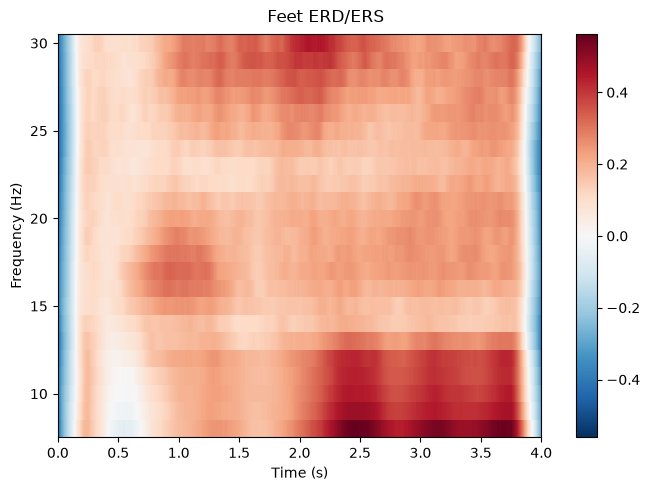

[<Figure size 640x480 with 2 Axes>]

In [59]:
import mne

channel_names=['C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3', 
        'CP4', 'CPz', 'Cz', 'FC2','FC3', 'FC4', 'FCz', 'P1', 
        'P2', 'POz', 'Pz', 'C1', 'FC1','Fz']

info = mne.create_info(
    ch_names=channel_names,
    sfreq=250,
    ch_types="eeg"
)

epochs = mne.EpochsArray(X, info)
feet_epochs = epochs[y == "feet"]
feet_epochs

freqs = np.arange(8, 31)
n_cycles = freqs / 2


power = mne.time_frequency.tfr_multitaper(
    feet_epochs,
    freqs=freqs,
    n_cycles=n_cycles,
    return_itc=False,
    average=True
)

power.apply_baseline(
    baseline=(0, 0.5),
    mode="percent"
)

power.plot(picks="Cz", title="Feet ERD/ERS")

Not setting metadata
5184 matching events found
No baseline correction applied
0 projection items activated
NOTE: tfr_multitaper() is a legacy function. New code should use .compute_tfr(method="multitaper").
Applying baseline correction (mode: percent)
No baseline correction applied


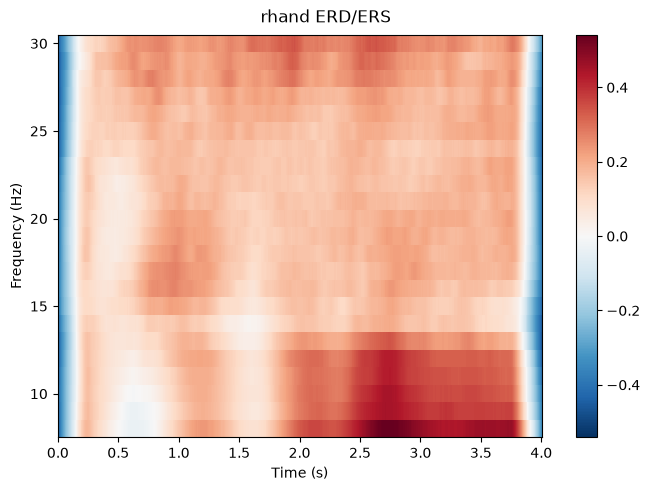

[<Figure size 640x480 with 2 Axes>]

In [62]:

epochs = mne.EpochsArray(X, info)
feet_epochs = epochs[y == "right_hand"]
feet_epochs

freqs = np.arange(8, 31)
n_cycles = freqs / 2


power = mne.time_frequency.tfr_multitaper(
    feet_epochs,
    freqs=freqs,
    n_cycles=n_cycles,
    return_itc=False,
    average=True
)

power.apply_baseline(
    baseline=(0, 0.5),
    mode="percent"
)

power.plot(picks="Cz", title="rhand ERD/ERS")

Not setting metadata
5184 matching events found


No baseline correction applied
0 projection items activated
NOTE: tfr_multitaper() is a legacy function. New code should use .compute_tfr(method="multitaper").
Applying baseline correction (mode: percent)
No baseline correction applied


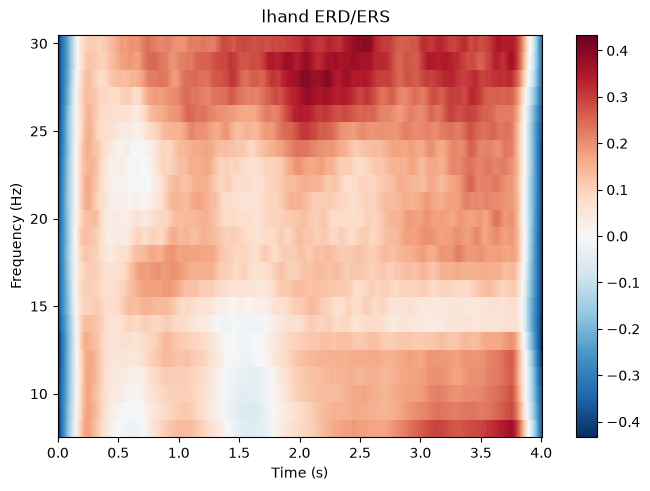

[<Figure size 640x480 with 2 Axes>]

In [63]:

epochs = mne.EpochsArray(X, info)
feet_epochs = epochs[y == "left_hand"]
feet_epochs

freqs = np.arange(8, 31)
n_cycles = freqs / 2


power = mne.time_frequency.tfr_multitaper(
    feet_epochs,
    freqs=freqs,
    n_cycles=n_cycles,
    return_itc=False,
    average=True
)

power.apply_baseline(
    baseline=(0, 0.5),
    mode="percent"
)

power.plot(picks="Cz", title="lhand ERD/ERS")

Not setting metadata
5184 matching events found
No baseline correction applied
0 projection items activated
NOTE: tfr_multitaper() is a legacy function. New code should use .compute_tfr(method="multitaper").
Applying baseline correction (mode: percent)
No baseline correction applied


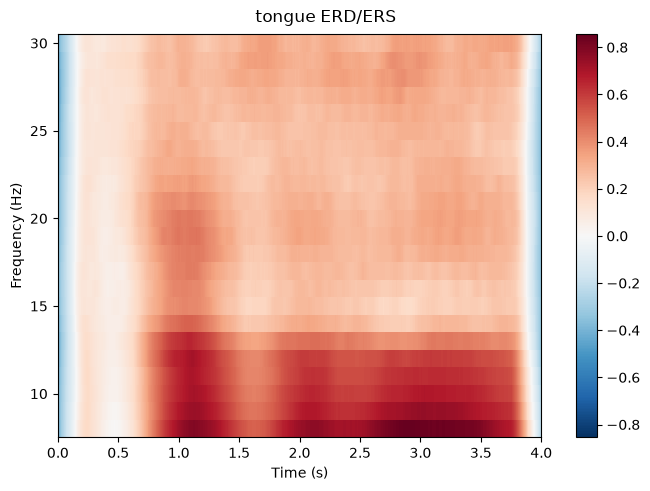

[<Figure size 640x480 with 2 Axes>]

In [64]:

epochs = mne.EpochsArray(X, info)
feet_epochs = epochs[y == "tongue"]
feet_epochs

freqs = np.arange(8, 31)
n_cycles = freqs / 2


power = mne.time_frequency.tfr_multitaper(
    feet_epochs,
    freqs=freqs,
    n_cycles=n_cycles,
    return_itc=False,
    average=True
)

power.apply_baseline(
    baseline=(0, 0.5),
    mode="percent"
)

power.plot(picks="Cz", title="tongue ERD/ERS")

## topo erd

X shape: (5184, 22, 1001)
y labels: ['feet' 'left_hand' 'right_hand' 'tongue']
Not setting metadata
5184 matching events found
No baseline correction applied
0 projection items activated
<EpochsArray | 5184 events (all good), 0 – 4 s (baseline off), ~871.0 MiB, data loaded,
 '1': 5184>
<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 22 channels>
NOTE: tfr_multitaper() is a legacy function. New code should use .compute_tfr(method="multitaper").
Applying baseline correction (mode: percent)
NOTE: tfr_multitaper() is a legacy function. New code should use .compute_tfr(method="multitaper").
Applying baseline correction (mode: percent)
NOTE: tfr_multitaper() is a legacy function. New code should use .compute_tfr(method="multitaper").
Applying baseline correction (mode: percent)
NOTE: tfr_multitaper() is a legacy function. New code should use .compute_tfr(method="multitaper").
Applying baseline correction (mode: percent)
No baseline correction applied


AttributeError: 'list' object has no attribute 'suptitle'

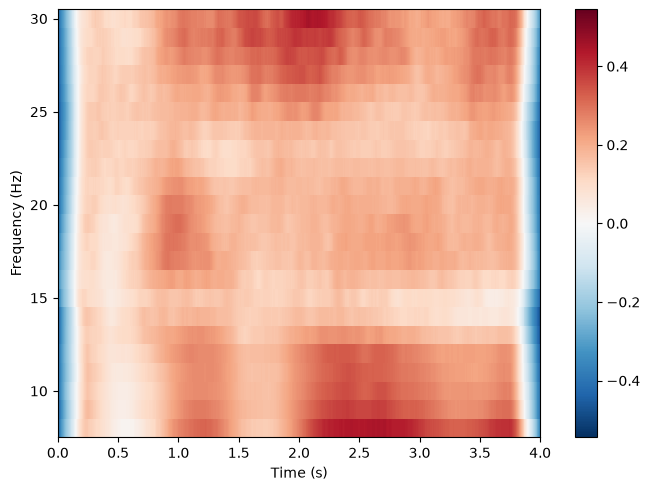

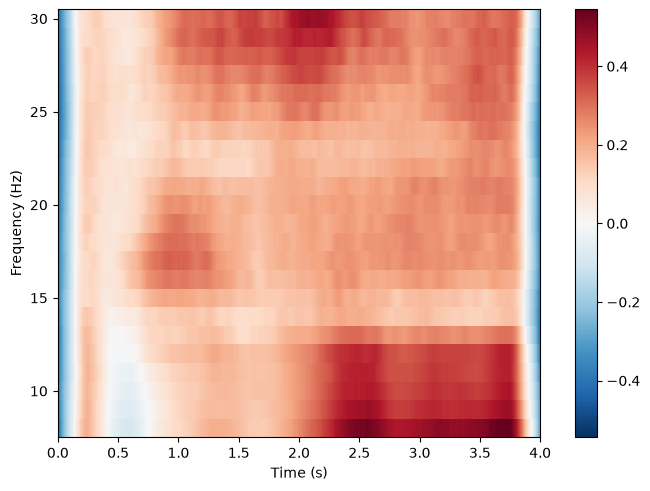

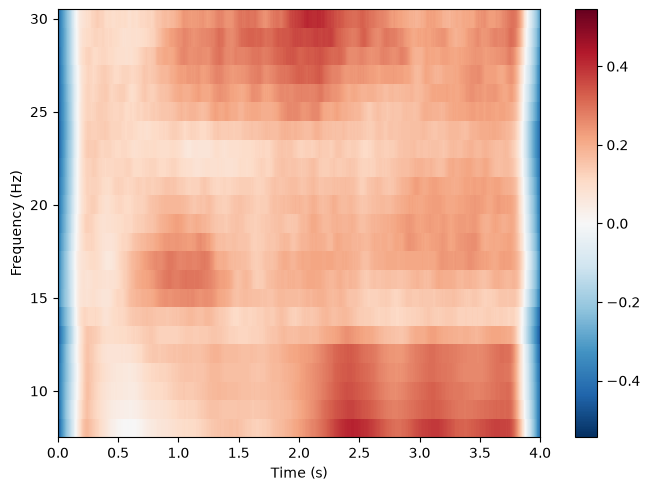

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mne

# -----------------------------
# 1. Check input shape
# -----------------------------
print("X shape:", X.shape)
print("y labels:", np.unique(y))

# Expected: X = trials x channels x time
# If your X is trials x time x channels, uncomment:
# X = np.transpose(X, (0, 2, 1))

# -----------------------------
# 2. Define EEG settings
# -----------------------------
sfreq = 250  # change if your sampling rate is different

channel_names = [
    "Fz",
    "FC3", "FC1", "FCz", "FC2", "FC4",
    "C5", "C3", "C1", "Cz", "C2", "C4", "C6",
    "CP3", "CP1", "CPz", "CP2", "CP4",
    "P1", "Pz", "P2",
    "POz"
]

# -----------------------------
# 3. Create MNE info with montage
# -----------------------------
info = mne.create_info(
    ch_names=channel_names,
    sfreq=sfreq,
    ch_types="eeg"
)

montage = mne.channels.make_standard_montage("standard_1020")
info.set_montage(montage)

epochs = mne.EpochsArray(X, info)

print(epochs)
print(epochs.info.get_montage())

# -----------------------------
# 4. Compute ERD/ERS power
# -----------------------------
freqs = np.arange(8, 31)
n_cycles = freqs / 2

powers = {}

for label in np.unique(y):
    class_epochs = epochs[y == label]

    power = mne.time_frequency.tfr_multitaper(
        class_epochs,
        freqs=freqs,
        n_cycles=n_cycles,
        return_itc=False,
        average=True
    )

    power.apply_baseline(
        baseline=(0, 0.5),
        mode="percent"
    )

    powers[label] = power


No baseline correction applied


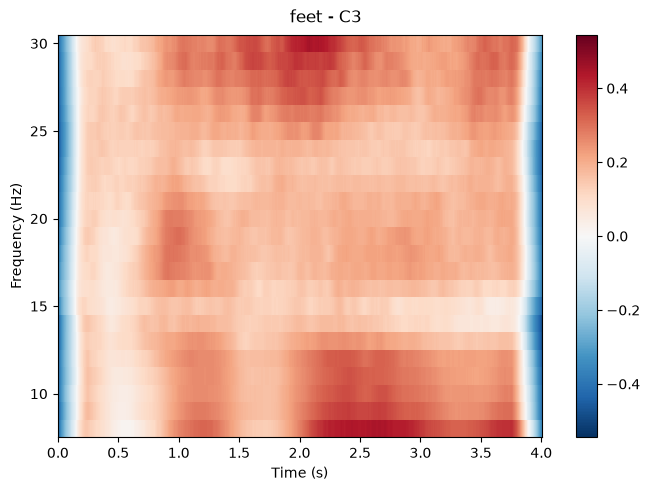

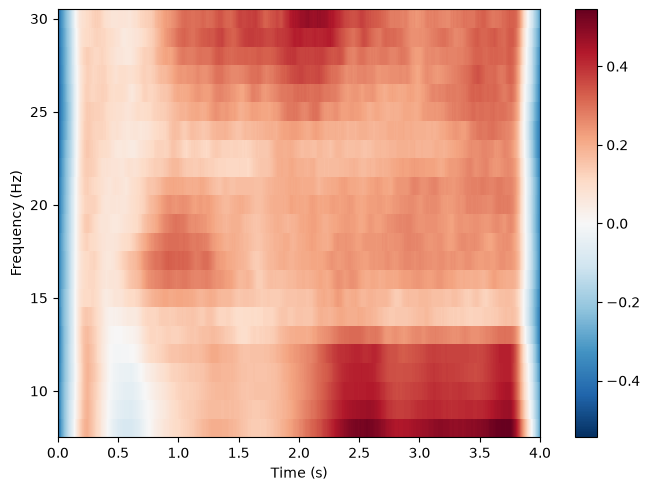

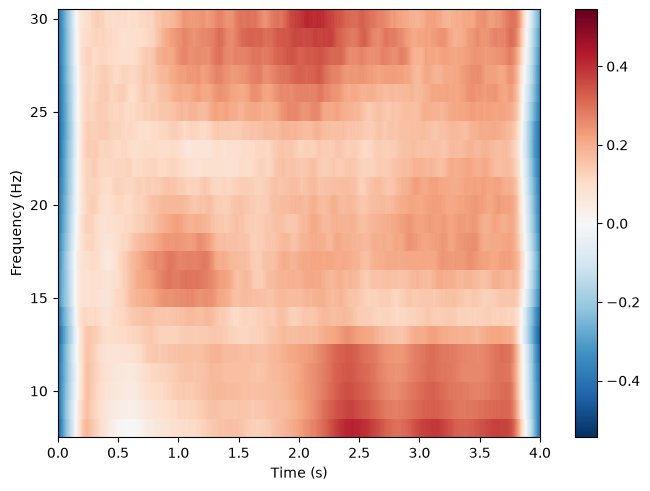

No baseline correction applied


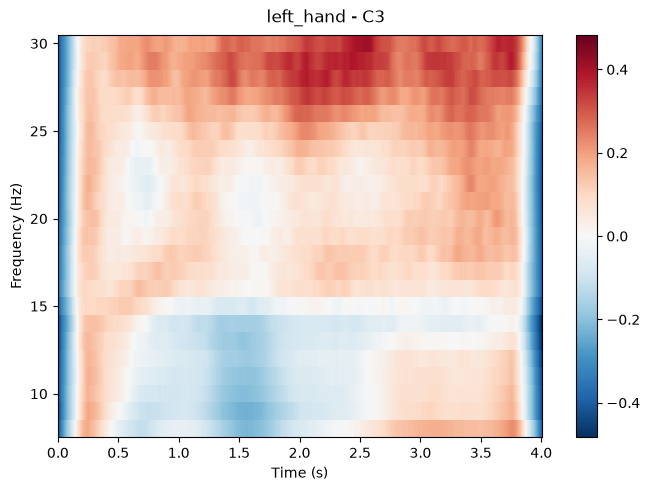

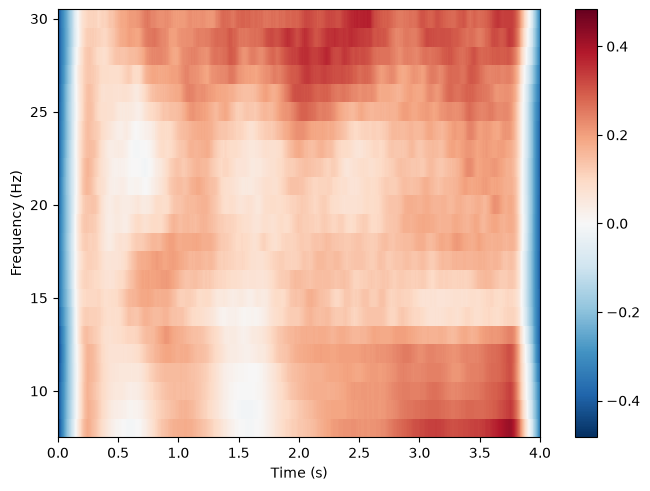

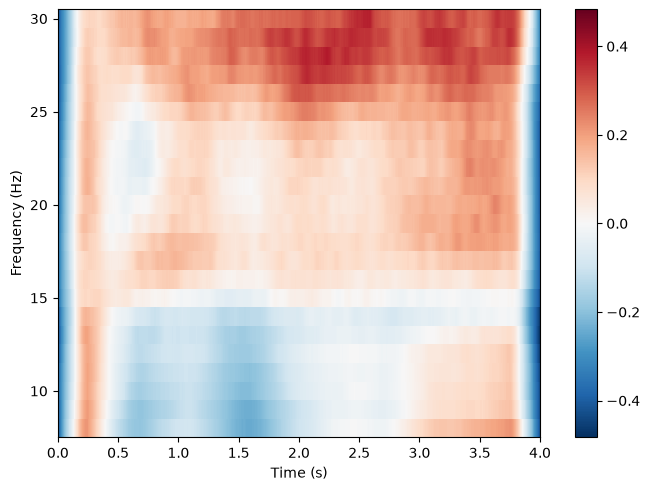

No baseline correction applied


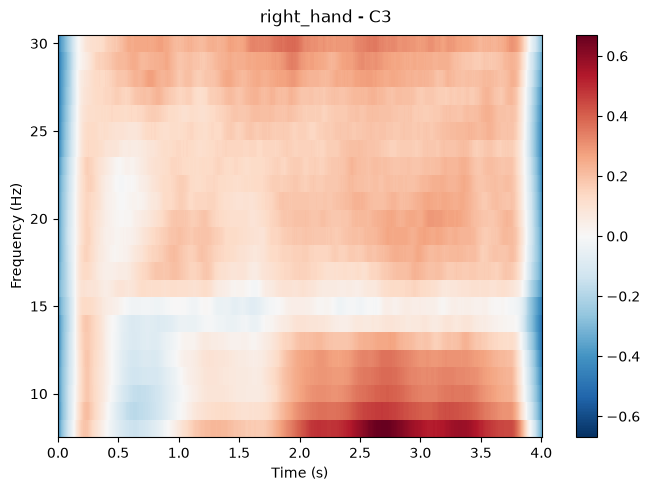

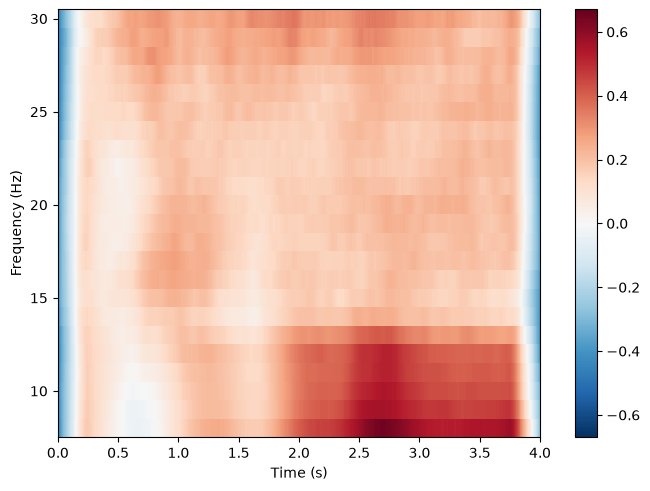

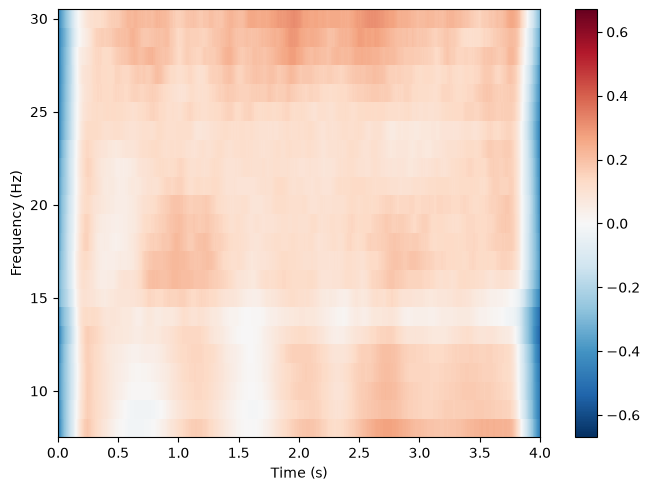

No baseline correction applied


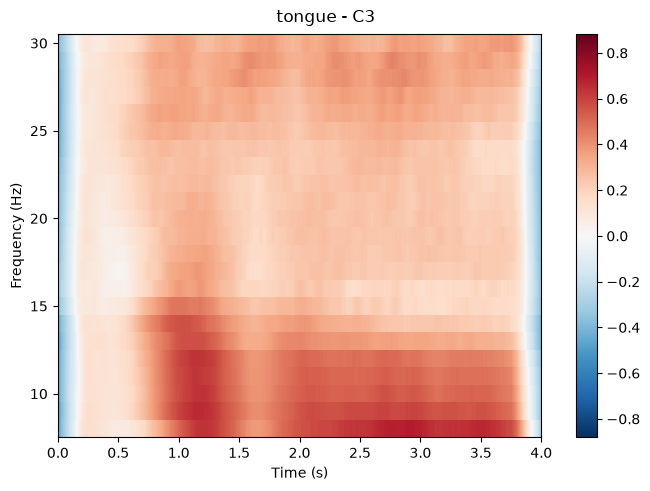

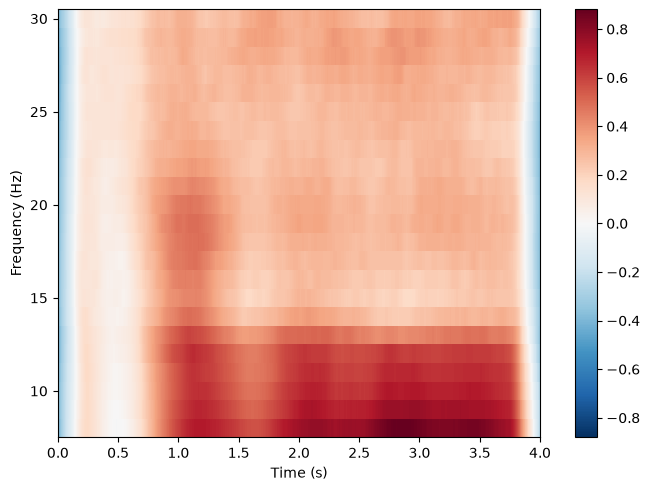

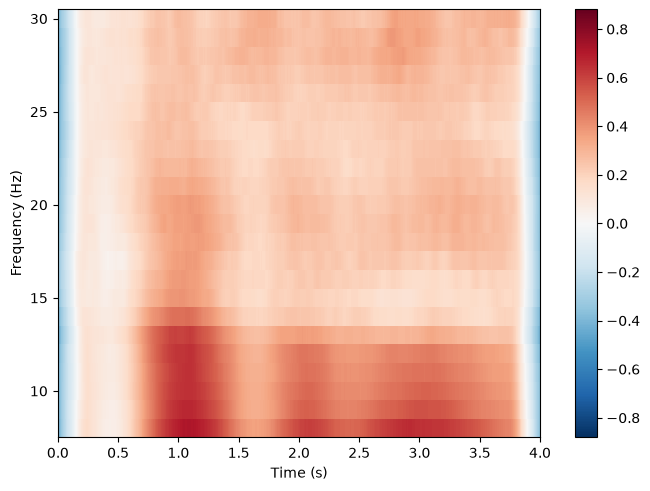

No baseline correction applied


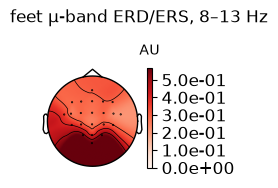

No baseline correction applied


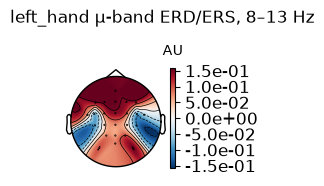

No baseline correction applied


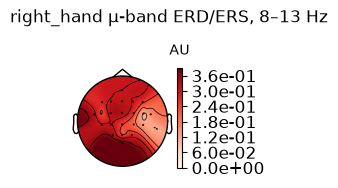

No baseline correction applied


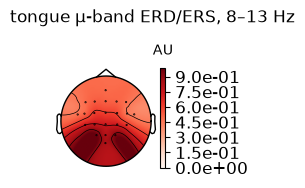

No baseline correction applied


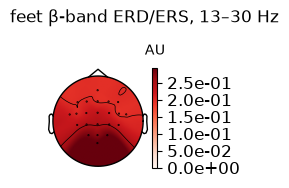

No baseline correction applied


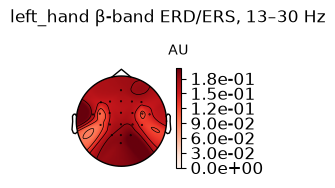

No baseline correction applied


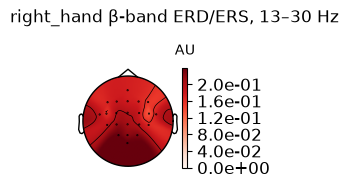

No baseline correction applied


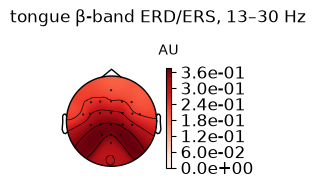

In [26]:

# -----------------------------
# 5. Plot C3, Cz, C4 ERD/ERS
# -----------------------------
channels_to_plot = ["C3", "Cz", "C4"]

for label, power in powers.items():
    figs = power.plot(
        picks=channels_to_plot,
        combine=None,
        show=False
    )

    for fig, ch in zip(figs, channels_to_plot):
        fig.suptitle(f"{label} - {ch}")
        plt.show()
        
# -----------------------------
# 6. Plot μ-band topomaps
# -----------------------------
for label, power in powers.items():
    fig = power.plot_topomap(
        tmin=1.0,
        tmax=3.0,
        fmin=8,
        fmax=13,
        show=False
    )
    fig.suptitle(f"{label} μ-band ERD/ERS, 8–13 Hz")
    plt.show()

# -----------------------------
# 7. Plot β-band topomaps
# -----------------------------
for label, power in powers.items():
    fig = power.plot_topomap(
        tmin=1.0,
        tmax=3.0,
        fmin=13,
        fmax=30,
        show=False
    )
    fig.suptitle(f"{label} β-band ERD/ERS, 13–30 Hz")
    plt.show()